# Демо 4. Плоские модельные задачи спутниковой навигации

*Источник:* П.А. Кручинин. Об освоении пакета MATLAB с использованием практических задач. Здесь задача переведена на Python.

## Постановка задачи

Приёмник $M$ с радиус-вектором $\vec r = (x, y)$ принимает сигналы спутников $S_k$, координаты $\vec r_k$ которых известны. По времени распространения сигнала определяется дальность $l_k = c\,(t - t_k)$ до каждого спутника. В плоской задаче координаты приёмника находятся из системы
$$
|\vec r - \vec r_1| = l_1, \qquad |\vec r - \vec r_2| = l_2 . \tag{4.1}
$$
Единица длины — 1000 км. Данные задачи: $\vec r_1 = (1, 7)$, $\vec r_2 = (5, 5)$, $l_1 = 2.5$, $l_2 = 2$.

**Что отрабатываем:** решение нелинейных уравнений (`scipy.optimize.brentq`, `fsolve`), передачу параметров через `args`, роль начального приближения, ложные корни.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq, fsolve

r1 = np.array([1.0, 7.0])
r2 = np.array([5.0, 5.0])
l1, l2 = 2.5, 2.0

## Способ 1: одно уравнение с одним неизвестным

Выразим $y$ из второго уравнения и подставим в первое:
$$
y = y_2 + \sigma\sqrt{l_2^2 - (x - x_2)^2}, \qquad \sigma = \pm 1 . \tag{4.2}
$$

Знак $\sigma$ определяет ветвь окружности. Решение, приведённое в исходной статье ($y \approx 5.67 > y_2 = 5$), лежит на ветви $\sigma = +1$, хотя в формуле статьи стоит знак «минус». На ветви $\sigma = -1$ при этих данных корней нет, проверьте это на графике ниже.

В MATLAB уравнение решалось функцией `fzero` с начальным приближением. Функция `brentq` требует отрезка $[a, b]$, на концах которого функция имеет разные знаки. Удобно сначала построить график. Кроме того, корень в (4.2) определён только при $|x - x_2| \le l_2$: вне этого отрезка функция возвращает `nan`.

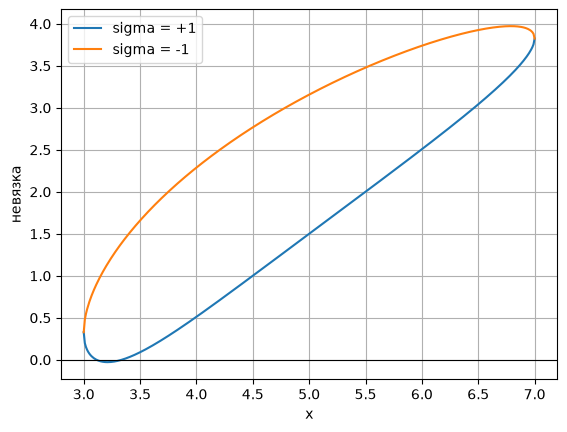

отрезок [3.0, 3.2]: r = (3.1139, 5.6653)
отрезок [3.2, 3.5]: r = (3.3361, 6.1097)


In [2]:
def gps1(x, l1, l2, r1, r2, sigma=+1):
    """Невязка первого уравнения после исключения y по формуле (4.2)."""
    y = r2[1] + sigma * np.sqrt(l2**2 - (x - r2[0])**2)
    return np.linalg.norm(r1 - np.array([x, y])) - l1


xs = np.linspace(r2[0] - l2, r2[0] + l2, 400)
with np.errstate(invalid='ignore'):
    for sigma in (+1, -1):
        plt.plot(xs, [gps1(x, l1, l2, r1, r2, sigma) for x in xs], label=f'sigma = {sigma:+d}')
plt.axhline(0, color='k', lw=0.8)
plt.xlabel('x')
plt.ylabel('невязка')
plt.legend()
plt.grid(True)
plt.show()

for a, b in [(3.0, 3.2), (3.2, 3.5)]:
    x = brentq(gps1, a, b, args=(l1, l2, r1, r2))
    y = r2[1] + np.sqrt(l2**2 - (x - r2[0])**2)
    print(f'отрезок [{a}, {b}]: r = ({x:.4f}, {y:.4f})')

## Способ 2: система двух уравнений

Функция `fsolve` решает систему (4.1) относительно $(x, y)$ сразу. Дополнительные параметры передаются кортежем `args`. В MATLAB для этого перечисляли параметры после пустых аргументов `[]`.

In [3]:
def gps2(r, l1, l2, r1, r2):
    """Невязки системы (4.1)."""
    return [np.linalg.norm(r - r1) - l1,
            np.linalg.norm(r - r2) - l2]


for r0 in ([3.0, 3.0], [3.3, 7.0]):
    r = fsolve(gps2, r0, args=(l1, l2, r1, r2))
    print(f'начальное приближение {r0}: r = ({r[0]:.4f}, {r[1]:.4f})')

начальное приближение [3.0, 3.0]: r = (3.1139, 5.6653)
начальное приближение [3.3, 7.0]: r = (3.3361, 6.1097)


Система имеет **два решения**: $\vec r = (3.1139, 5.6653)$ и $\vec r_* = (3.3361, 6.1097)$. Какое из них найдёт `fsolve`, зависит от начального приближения. Второе решение ложное: оно соответствует точке на высоте около 500 км над поверхностью Земли. Отбросить его можно по этой дополнительной информации или по сигналу третьего спутника.

Геометрически решения — это точки пересечения двух окружностей:

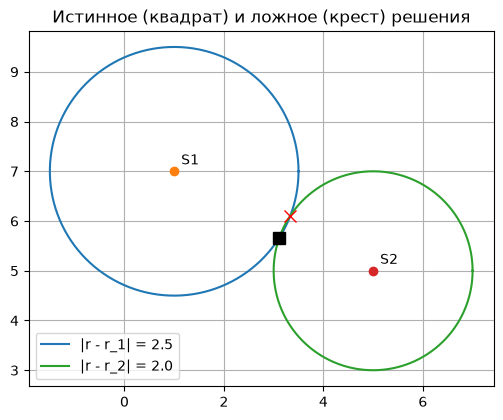

In [4]:
th = np.linspace(0, 2 * np.pi, 400)
fig, ax = plt.subplots(figsize=(6, 6))
for rk, lk, name in [(r1, l1, 'S1'), (r2, l2, 'S2')]:
    ax.plot(rk[0] + lk * np.cos(th), rk[1] + lk * np.sin(th), label=f'|r - r_{name[1]}| = {lk}')
    ax.plot(*rk, 'o')
    ax.annotate(name, rk, textcoords='offset points', xytext=(5, 5))
for r0, mark in (([3.0, 3.0], 'ks'), ([3.3, 7.0], 'rx')):
    ax.plot(*fsolve(gps2, r0, args=(l1, l2, r1, r2)), mark, ms=9)
ax.set_aspect('equal')
ax.grid(True)
ax.legend(loc='lower left')
ax.set_title('Истинное (квадрат) и ложное (крест) решения')
plt.show()

## Ошибка синхронизации часов приёмника

Пусть часы приёмника имеют систематическую ошибку $\Delta t$. Тогда приёмник измеряет не дальности, а **псевдодальности** $l_k^* = l_k + e$, где $e = c\,\Delta t$. Разности уравнений
$$
|\vec r - \vec r_2| - |\vec r - \vec r_1| = l_2^* - l_1^*, \qquad
|\vec r - \vec r_3| - |\vec r - \vec r_1| = l_3^* - l_1^*
$$
уже не содержат $e$, но требуют третьего спутника. Данные: $\vec r_3 = (6, 3)$, $l_3^* = 3.92$.

(В комментарии к функции `gps3` в исходной статье по ошибке вызывается `gps2`. Здесь используется правильная функция.)

In [5]:
r3 = np.array([6.0, 3.0])
l3 = 3.92


def gps3(r, l1, l2, l3, r1, r2, r3):
    """Разности псевдодальностей: ошибка часов приёмника исключена."""
    return [np.linalg.norm(r2 - r) - l2 - np.linalg.norm(r1 - r) + l1,
            np.linalg.norm(r3 - r) - l3 - np.linalg.norm(r1 - r) + l1]


r = fsolve(gps3, [3.0, 3.0], args=(l1, l2, l3, r1, r2, r3))
e = np.linalg.norm(r - r1) - l1          # оценка ошибки c*dt по найденной точке
print(f'r = ({r[0]:.4f}, {r[1]:.4f}),  e = c*dt = {e:.4f}')

r = (3.1047, 5.6463),  e = c*dt = 0.0025


**Что попробовать:**
- найдите начальные приближения, при которых `fsolve` для `gps3` сходится к другому решению;
- переформулируйте задачу для трёхмерного случая (понадобятся четыре спутника);
- замените `fsolve` на `scipy.optimize.root` и сравните сообщения о сходимости (`sol.success`, `sol.message`).